# Mappint with Cartopy at different region 

## P3-Using cartopy for mapping
### Three maps will be produced using Cartopy, Matplotlib, Geocoders and numpy to visualise the produced maps. The maps includes the following regions:
- The Antarctic continent and the Southern Ocean starting from 60°S
- The South Atlantic Ocean, from 20°S to 50°S. The should show the following locations: Walvis Bay, Cape Town, Rio de Janeiro, Montevideo
- A series of 3 panels showing the use of different coastline resolutions from the GSHHG database in a map of False Bay. Display the coarse, intermediate and full resolution.

#### Import libraries

In [26]:
#importing statement labraries
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy
from geopy.geocoders import Nominatim
from geopy.distance import geodesic 

## Map 1: Antarctic Continent and Southern Ocean (South of 60°S)
This map will show the Antarctic continent and the surrounding of the Southern Ocean south of 60°S. A **South Polar Stereographic projection** was chosen because it shows a clearly display of the Antarctic Continent and the Southern Ocean. Gridlines, coordinate labels, ocean and land color were added, region line along the coast.

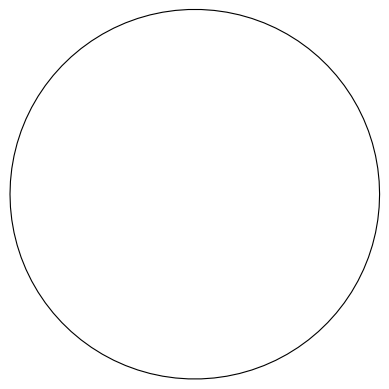

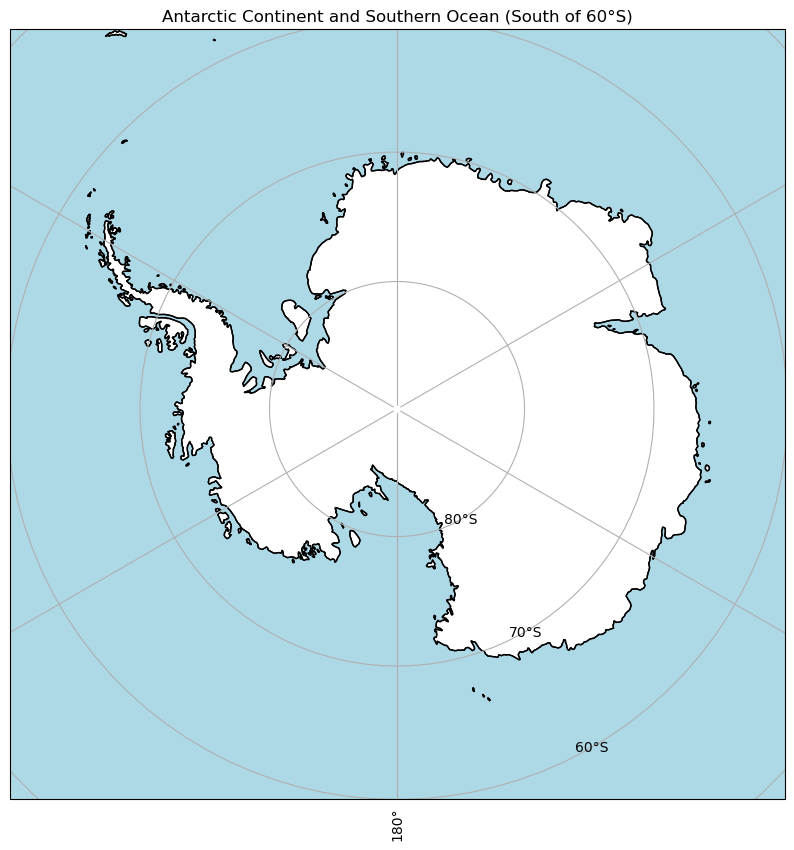

In [31]:
# Setting axes using the South Polar projection and coordinate system
ccrs.SouthPolarStereo(central_longitude=0.0, true_scale_latitude=None, globe=None)
ccrs.PlateCarree(central_longitude=0.0, globe=None)

# creating axes South Polar Stereographic projection and plotting figure (size)
plt.axes(projection=ccrs.SouthPolarStereo())
fig = plt.figure(figsize=(10,10))

# Defining axes and and adding coastline 
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.coastlines()

# Setting extent by defining the coordinate system and PlateCarree coordinate system
extent = [-180,180,-90,-60]
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Adding gridlines and setting labels 
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Add features to the map
ax.add_feature(cfeature.LAND, facecolor='white')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.RIVERS, edgecolor='blue')
ax.add_feature(cfeature.LAKES, facecolor='lightblue')

# Adding map title
plt.title("Antarctic Continent and Southern Ocean (South of 60°S)")
plt.show()


## Map 2: South Atlantic with Cities 
Region: South Atlantic Ocean
Cities to plot:
- Walvis Bay
- Cape Town
- Rio de Janeiro
- Montevideo
  
This map will be showing the South Atlantic Ocean between 20°S and 50°S. A **EquidistantConic projection** was used to produce the South Atlantic ocean with the above listed cities, because it directly represents latitude and longitude coordinates, making it suitable for plotting geographic locations. This projection clearly displays the South Atlantic Ocean, coastlines cities that are influence by this Ocean and their continent.

[Location(Cape Town, City of Cape Town, Western Cape, 8001, South Africa, (-33.9288301, 18.4172197, 0.0)), Location(Walvis Bay, Erongo Region, 13013, Namibia, (-22.9557607, 14.5071125, 0.0)), Location(Rio de Janeiro, Região Geográfica Imediata do Rio de Janeiro, Região Metropolitana do Rio de Janeiro, Região Geográfica Intermediária do Rio de Janeiro, Rio de Janeiro, Southeast Region, Brazil, (-22.9110137, -43.2093727, 0.0)), Location(Montevideo, Uruguay, (-34.9058916, -56.1913095, 0.0))]


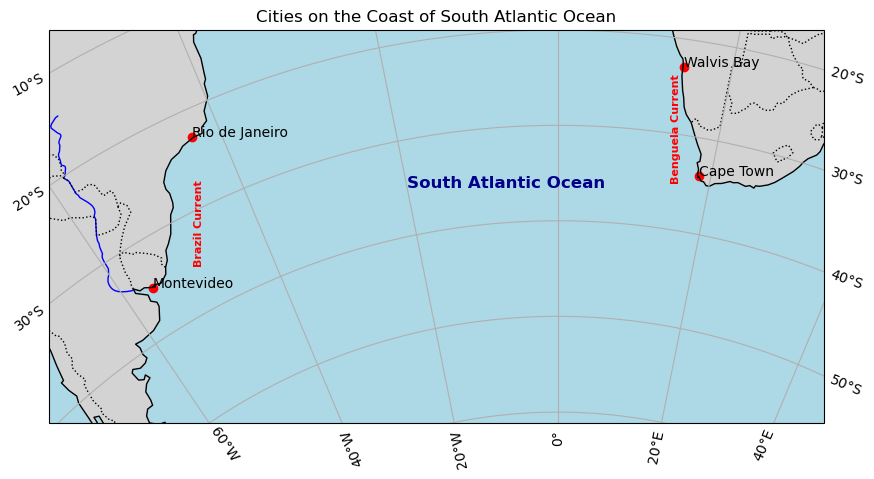

In [61]:
# Defining EquidistanctConic projections and setting coordinate system
proj = ccrs.EquidistantConic(central_longitude=0.0, central_latitude=-30.0, standard_parallels=(-20.0, -50.0))
ccrs.PlateCarree(central_longitude=0.0, globe=None)

# Creating figure size, axes projuection and adding coastlines axes
plt.figure(figsize=(10,8))
ax = plt.axes(projection=proj)
ax.coastlines()

# Setting extent by defining the coordinate system
extent = [-60, 30, -50, -20]
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Adding gridlines and setting grid labels on each sides
gl = ax.gridlines(draw_labels=True)
gl.right_labels = True
gl.top_labels = False

# Adding Locations on the map and Geocoder
geolocator = Nominatim(user_agent='educational')
places = ['Cape Town', 'Walvis Bay', 'Rio de Janeiro', 'Montevideo']
addresses = []

for p in places:
    loc = geolocator.geocode(p, language="en")
    addresses.append(loc)
#Printing address
print(addresses)

# Plotting locations and adding point of reference for each location
for i in range(len(places)):
    
    ax.scatter(addresses[i].longitude,
               addresses[i].latitude,
               color='red',
               transform=ccrs.PlateCarree())

    ax.text(addresses[i].longitude,
            addresses[i].latitude,
            places[i],
            transform=ccrs.Geodetic(),
            rotation=0,
            fontsize=10)

# Adding features on the map
ax.add_feature(cfeature.LAND, facecolor="lightgrey")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.RIVERS, edgecolor='blue')

ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAKES, facecolor='lightblue')

# Ocean label
ax.text(-20, -35, "South Atlantic Ocean",
        transform=ccrs.PlateCarree(),
        fontsize=12, color='darkblue', fontweight='bold')

# Major ocean currents
ax.text(15, -35, "Benguela Current",
        transform=ccrs.PlateCarree(),
        fontsize=8, color='red',fontweight='bold', rotation=90)
ax.text(-50, -35, "Brazil Current",
        transform=ccrs.PlateCarree(),
        fontsize=8, color='red',fontweight='bold', rotation=90)

# Adding map title
plt.title("Cities on the Coast of South Atlantic Ocean")
plt.show()

## Map 3: Coastline Resolution Comparison in False Bay

This map will show a series of 3 panels from the GSHHG coastline database in a map of False Bay. The **Mercator projections** will show resolutions that includes:
- Coarse (110m)
- intermediate (50m)
- full resolution (10m).

These comparsion display how coastline increases with higher resesoluting in False Bay, showing the city of Cape Town and the location of False Bay. Coordinates labels are added on each side of the panel showing both latitude and longitude(East and South), gridlines and a title and subtitle for each panel.

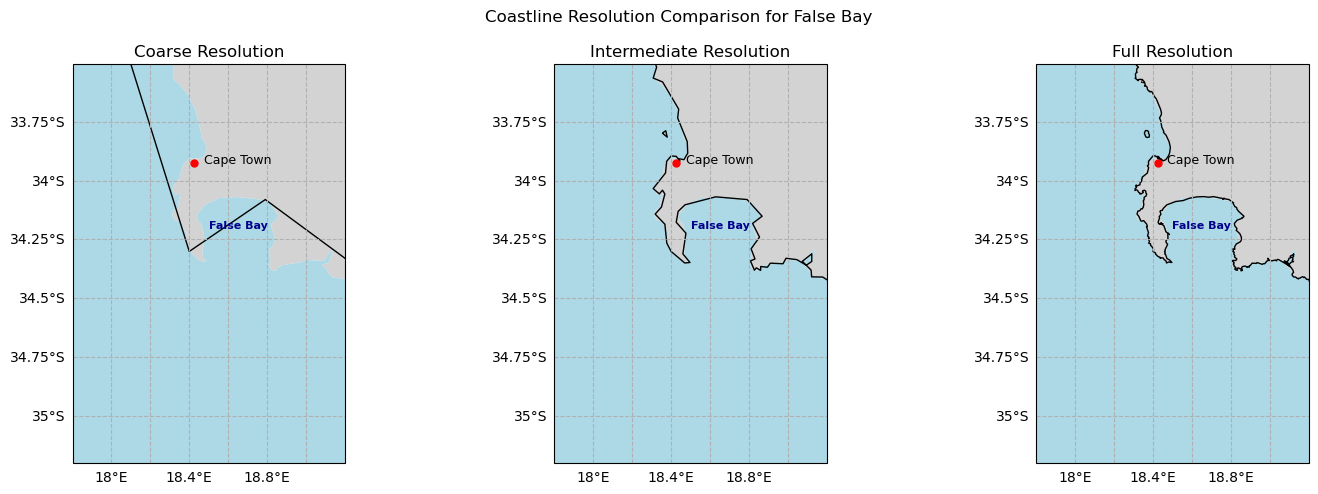

In [37]:
# Define coastline features from GSHHG
cl_coarse = cfeature.GSHHSFeature(scale='c')
cl_intermediate = cfeature.GSHHSFeature(scale='i')
cl_full = cfeature.GSHHSFeature(scale='h')

# Map extent for False Bay
extent = [17.8, 19.2, -35.2, -33.5]

# Setting figure parameters using Mercatoe projection
fig, ax = plt.subplots(1, 3, figsize=(15,5),
                       subplot_kw={'projection': ccrs.Mercator()})

# Plotting 3 panels map
ax[0].set_extent(extent, crs=ccrs.PlateCarree())
ax[0].add_feature(cfeature.LAND, facecolor='lightgray')
ax[0].add_feature(cfeature.OCEAN, facecolor='lightblue')

ax[1].set_extent(extent, crs=ccrs.PlateCarree())
ax[1].add_feature(cfeature.LAND, facecolor='lightgray')
ax[1].add_feature(cfeature.OCEAN, facecolor='lightblue')

ax[2].set_extent(extent, crs=ccrs.PlateCarree())
ax[2].add_feature(cfeature.LAND, facecolor='lightgray')
ax[2].add_feature(cfeature.OCEAN, facecolor='lightblue')

# List of coastlines and sub-titles
coastlines = [cl_coarse, cl_intermediate, cl_full]
titles = ['Coarse Resolution', 'Intermediate Resolution', 'Full Resolution']

# Cape Town coordinates
cape_town_lon = 18.4241
cape_town_lat = -33.9249

# Add coastlines, gridlines, titles and mao features
for a, coast, title in zip(ax, coastlines, titles):
    a.add_feature(coast, edgecolor='black')
    
    # Additional map features
    a.add_feature(cfeature.BORDERS, linestyle=':')
    a.add_feature(cfeature.RIVERS, edgecolor='blue',linewidth=0.5)
    a.add_feature(cfeature.LAKES, facecolor='lightblue')

    # Gridlines
    gl = a.gridlines(draw_labels=True, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    # Cape Town marker
    a.plot(cape_town_lon, cape_town_lat, 'ro',
           transform=ccrs.PlateCarree(), markersize=5)

    a.text(cape_town_lon+0.05, cape_town_lat,
           "Cape Town",
           transform=ccrs.PlateCarree(),
           fontsize=9)

    # False Bay label
    a.text(18.5, -34.2,
           "False Bay",
           transform=ccrs.PlateCarree(),
           fontsize=8,
           color='darkblue',
           fontweight='bold')
    a.set_title(title)
# Adding title 
plt.suptitle("Coastline Resolution Comparison for False Bay")

plt.tight_layout()
plt.show()